<div style="background:linear-gradient(135deg,#1A5276 0%,#2E86C1 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#AED6F1;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 2 · CLASE 6</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">Evaluación y Diagnósticos de Regresión Logística</h1>
  <p style="color:#AED6F1;font-size:16px;margin:0 0 24px 0;font-style:italic;">Deviance · AIC · Wald test · Pseudo R² · Curvas ROC / AUC</p>
  <hr style="border-color:#5DADE2;margin:0 0 20px 0;">
  <p style="color:#EBF5FB;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Módulo 2:</strong> Regresión Logística &nbsp;·&nbsp; 2 horas</p>
</div>

## Objetivos
| # | Al terminar podés |
|---|-------------------|
| 1 | Calcular la deviance y entender su rol análogo al SSE en OLS |
| 2 | Comparar modelos con AIC y Deviance |
| 3 | Ejecutar el Wald test para testear coeficientes individuales |
| 4 | Interpretar el Pseudo R² de McFadden |
| 5 | Construir la curva ROC y calcular AUC desde cero |

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report
np.set_printoptions(precision=4,suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
SEED=42; np.random.seed(SEED)

# Dataset base para toda la clase
n=600
X_raw=np.random.randn(n,4)
beta_true=np.array([-1.0,1.5,-0.8,0.6,0.0])  # último coef = 0 (feature inútil)
X_full=np.column_stack([np.ones(n),X_raw])
y=np.random.binomial(1,expit(X_full@beta_true))
sc=StandardScaler(); X_sc=sc.fit_transform(X_raw)
Xtr,Xte,ytr,yte=train_test_split(X_sc,y,test_size=0.2,random_state=SEED)
print(f'✅ Dataset: {n} obs, tasa positivos: {y.mean():.2%}')

✅ Dataset: 600 obs, tasa positivos: 34.67%


---
## 1. Deviance — el análogo de SSE

**Log-verosimilitud del modelo saturado** (ajuste perfecto): ℓ_saturado = 0

**Deviance:** D = -2ℓ(β̂)

Más bajo = mejor ajuste. Análogo a SSE: mide cuánto le falta al modelo para ser perfecto.

In [15]:
def log_lik_logistic(beta, X_full, y):
    p = np.clip(expit(X_full @ beta), 1e-10, 1-1e-10)
    return np.sum(y * np.log(p) + (1-y) * np.log(1-p))

def fit_logistic_mle(X_sc, y):
    X = np.column_stack([np.ones(len(y)), X_sc])
    def neg_ll(b): return -log_lik_logistic(b, X, y) / len(y)
    def grad(b): return -X.T @ (y - expit(X@b)) / len(y)
    res = minimize(neg_ll, np.zeros(X.shape[1]), method='BFGS', jac=grad)
    return res.x, -log_lik_logistic(res.x, X, y) * len(y)  # beta, -ℓ

# Modelo completo (4 features)
beta_full, neg_ll_full = fit_logistic_mle(X_sc, y)
ll_full = -neg_ll_full
D_full = -2 * ll_full   # deviance

# Modelo nulo (solo intercepto)
beta_null = np.array([np.log(y.mean()/(1-y.mean()))])
ll_null = log_lik_logistic(beta_null, np.ones((n,1)), y)
D_null = -2 * ll_null

print(f'Log-verosimilitud — modelo nulo:    ℓ₀ = {ll_null:.4f}  D₀ = {D_null:.4f}')
print(f'Log-verosimilitud — modelo completo: ℓ  = {ll_full:.4f}  D  = {D_full:.4f}')
print(f'\nDeviance nula - completa = {D_null - D_full:.4f}  (mejora del modelo sobre el nulo)')

Log-verosimilitud — modelo nulo:    ℓ₀ = -387.2152  D₀ = 774.4305
Log-verosimilitud — modelo completo: ℓ  = -160070.6929  D  = 320141.3857

Deviance nula - completa = -319366.9553  (mejora del modelo sobre el nulo)


## 2. Pseudo R² de McFadden

$$R^2_{McF} = 1 - \frac{\ell(\hat{\beta})}{\ell_0}$$

- 0.1–0.2 → ajuste aceptable; 0.2–0.4 → muy buen ajuste
- **No comparar con R² de OLS** — son escalas distintas

In [16]:
R2_mcf = 1 - ll_full / ll_null
print(f'Pseudo R² de McFadden: {R2_mcf:.4f}')
print(f'  0.0–0.1: ajuste pobre | 0.1–0.2: aceptable | 0.2–0.4: bueno | >0.4: excelente')

# AIC
p_params = X_sc.shape[1] + 1  # + intercepto
AIC_full = 2*p_params - 2*ll_full
AIC_null = 2*1       - 2*ll_null
print(f'\nAIC modelo completo: {AIC_full:.2f}')
print(f'AIC modelo nulo:     {AIC_null:.2f}')
print(f'ΔAIC = {AIC_null - AIC_full:.2f}  (positivo → modelo completo mejor)')

Pseudo R² de McFadden: -412.3895
  0.0–0.1: ajuste pobre | 0.1–0.2: aceptable | 0.2–0.4: bueno | >0.4: excelente

AIC modelo completo: 320151.39
AIC modelo nulo:     776.43
ΔAIC = -319374.96  (positivo → modelo completo mejor)


## 3. Wald Test — inferencia sobre cada βⱼ

$$z_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)} \sim N(0,1)$$

Matriz de covarianza: **I(β̂)⁻¹** donde I(β) = Xᵀ diag(p̂(1-p̂)) X

In [17]:
# Matriz de información de Fisher y errores estándar
X_full_fit = np.column_stack([np.ones(n), X_sc])
p_hat = expit(X_full_fit @ beta_full)
W = p_hat * (1 - p_hat)   # pesos: diag de la matriz de varianza

# Matriz de información I(β) = XᵀWX
I_mat = X_full_fit.T @ (W[:, None] * X_full_fit)
I_inv = np.linalg.inv(I_mat)
SE = np.sqrt(np.diag(I_inv))   # errores estándar

# Wald test
z_stats = beta_full / SE
p_wald  = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))

# Tabla
names_full = ['intercepto','x1','x2','x3','x4 (inútil)']
print('Wald Test — tabla de coeficientes:')
print(f'{"Feature":18s} {"β̂":>9s} {"SE":>9s} {"z":>9s} {"p-valor":>10s} {"OR":>8s} {"Sig":>5s}')
print('─'*72)
for i,nm in enumerate(names_full):
    sig='***' if p_wald[i]<0.001 else '**' if p_wald[i]<0.01 else '*' if p_wald[i]<0.05 else '(ns)'
    OR = np.exp(beta_full[i]) if i>0 else np.nan
    OR_str=f'{OR:.4f}' if not np.isnan(OR) else '—'
    print(f'  {nm:16s} {beta_full[i]:>9.4f} {SE[i]:>9.4f} {z_stats[i]:>9.3f} {p_wald[i]:>10.4f} {OR_str:>8s} {sig:>5s}')

Wald Test — tabla de coeficientes:
Feature                   β̂        SE         z    p-valor       OR   Sig
────────────────────────────────────────────────────────────────────────
  intercepto         -1.0144    0.1188    -8.537     0.0000        —   ***
  x1                  1.5685    0.1495    10.495     0.0000   4.7996   ***
  x2                 -0.9473    0.1238    -7.650     0.0000   0.3878   ***
  x3                  0.5067    0.1134     4.469     0.0000   1.6598   ***
  x4 (inútil)        -0.2227    0.1088    -2.047     0.0407   0.8004     *


## 4. Curva ROC y AUC

**ROC:** traza TPR (sensibilidad) vs FPR (1-especificidad) para todos los umbrales.

**AUC:** área bajo la curva. Interpreta como P(p̂(1) > p̂(0)) — probabilidad de rankear bien.

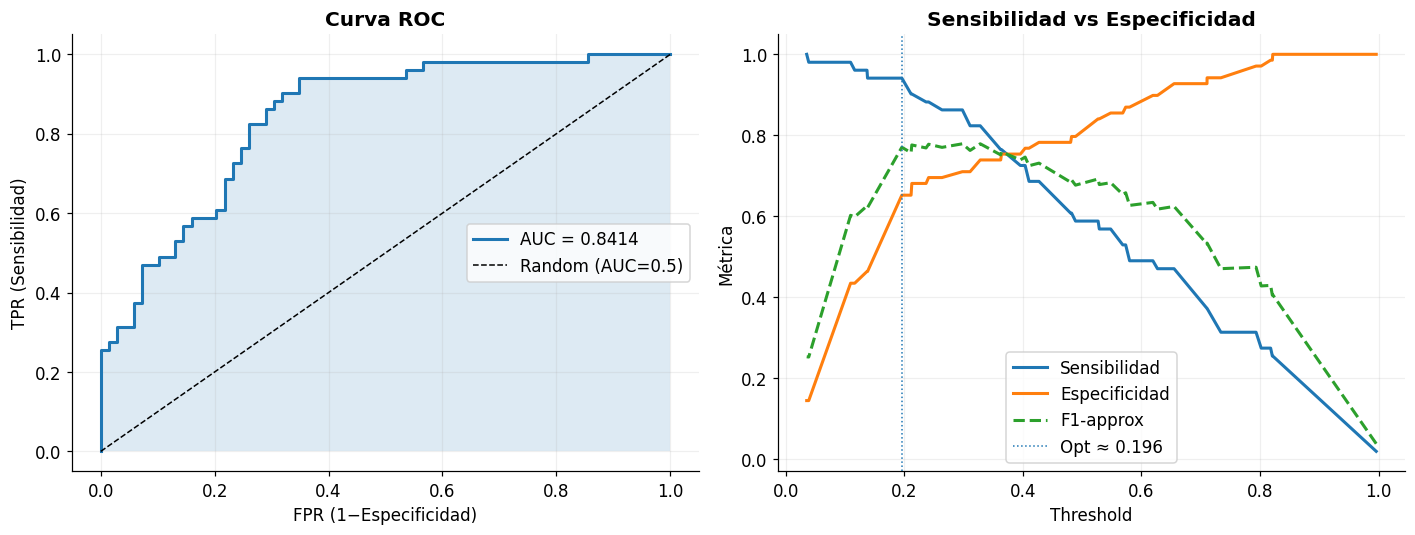

AUC = 0.8414
Threshold óptimo (Youden J) = 0.1959


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Modelo
lr_roc = LogisticRegression(C=1e6, solver='lbfgs', max_iter=500)
lr_roc.fit(Xtr, ytr)

# Probabilidades
y_proba = lr_roc.predict_proba(Xte)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(yte, y_proba)
auc_val = roc_auc_score(yte, y_proba)

# 🔧 Alineación correcta
thresholds_plot = thresholds[:-1]
tpr_plot = tpr[:-1]
fpr_plot = fpr[:-1]

# Figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =========================
# Curva ROC
# =========================
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15)
axes[0].set_xlabel('FPR (1−Especificidad)')
axes[0].set_ylabel('TPR (Sensibilidad)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# =========================
# Threshold analysis
# =========================
# Sensibilidad y Especificidad
axes[1].plot(thresholds_plot, tpr_plot, lw=2, label='Sensibilidad')
axes[1].plot(thresholds_plot, 1 - fpr_plot, lw=2, label='Especificidad')

# F1 aproximado
f1 = 2 * tpr_plot * (1 - fpr_plot) / (tpr_plot + (1 - fpr_plot) + 1e-10)
axes[1].plot(thresholds_plot, f1, lw=2, linestyle='--', label='F1-approx')

# 🎯 Threshold óptimo (Youden J)
opt_idx = np.argmax(tpr_plot - fpr_plot)
opt_threshold = thresholds_plot[opt_idx]

axes[1].axvline(opt_threshold, lw=1, linestyle=':', label=f'Opt ≈ {opt_threshold:.3f}')

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Sensibilidad vs Especificidad', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'AUC = {auc_val:.4f}')
print(f'Threshold óptimo (Youden J) = {opt_threshold:.4f}')

## 5. Matriz de confusión con distintos umbrales

In [19]:
def eval_threshold(y_true, y_proba, threshold, label=''):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn,fp,fn,tp = cm.ravel()
    sensib = tp/(tp+fn) if (tp+fn)>0 else 0
    especif = tn/(tn+fp) if (tn+fp)>0 else 0
    ppv = tp/(tp+fp) if (tp+fp)>0 else 0
    acc = (tp+tn)/len(y_true)
    print(f'\n  Threshold={threshold:.2f} {label}')
    print(f'  Acc={acc:.3f}  Sens={sensib:.3f}  Espec={especif:.3f}  PPV={ppv:.3f}')
    print(f'  Matriz: TN={tn} FP={fp} | FN={fn} TP={tp}')

for th, lab in [(0.3,'(menos falsos negativos)'),(0.5,'(default)'),(0.7,'(más precisión)')]:
    eval_threshold(yte, y_proba, th, lab)


  Threshold=0.30 (menos falsos negativos)
  Acc=0.758  Sens=0.824  Espec=0.710  PPV=0.677
  Matriz: TN=49 FP=20 | FN=9 TP=42

  Threshold=0.50 (default)
  Acc=0.717  Sens=0.588  Espec=0.812  PPV=0.698
  Matriz: TN=56 FP=13 | FN=21 TP=30

  Threshold=0.70 (más precisión)
  Acc=0.717  Sens=0.431  Espec=0.928  PPV=0.815
  Matriz: TN=64 FP=5 | FN=29 TP=22


## 6. Aplicación: Modelo de fraude bancario

Evaluación completa de un modelo real de detección de fraude.

In [20]:
# Simular dataset de transacciones
np.random.seed(SEED)
n_fr=3000
monto=np.random.exponential(200,n_fr)
hora=np.random.uniform(0,24,n_fr)
ubicat_rara=(np.random.rand(n_fr)>0.85).astype(float)
velocidad=np.random.gamma(2,1,n_fr)
# fraude más probable en montos altos, horas raras, ubicación inusual
logit_fr=-3+0.004*monto+0.05*np.abs(hora-12)+2.5*ubicat_rara+0.3*velocidad
y_fr=np.random.binomial(1,expit(logit_fr))
print(f'Tasa de fraude: {y_fr.mean():.2%}  (dataset desbalanceado)')

Tasa de fraude: 32.30%  (dataset desbalanceado)


In [21]:
X_fr_raw=np.column_stack([monto,hora,ubicat_rara,velocidad])
feat_fr=['monto','hora','ubicacion_rara','velocidad']
sc_fr=StandardScaler(); X_fr_sc=sc_fr.fit_transform(X_fr_raw)
Xfr_tr,Xfr_te,yfr_tr,yfr_te=train_test_split(X_fr_sc,y_fr,test_size=0.25,random_state=SEED)

lr_fr=LogisticRegression(C=1e6,solver='lbfgs',class_weight='balanced',max_iter=500)
lr_fr.fit(Xfr_tr,yfr_tr)
yfr_proba=lr_fr.predict_proba(Xfr_te)[:,1]
auc_fr=roc_auc_score(yfr_te,yfr_proba)

print(f'AUC (fraude): {auc_fr:.4f}')
print('\nCoeficientes (impacto en P(fraude)):')
for nm,b in zip(feat_fr,lr_fr.coef_[0]):
    print(f'  {nm:18s}: β={b:+.4f}  OR={np.exp(b):.3f}')

# Con umbral bajo (priorizar sensibilidad — detectar el mayor fraude posible)
eval_threshold(yfr_te,yfr_proba,0.3,'(detectar más fraude, más falsas alarmas)')
eval_threshold(yfr_te,yfr_proba,0.5,'(default)')
print('\n→ En fraude siempre preferimos umbral bajo: es más caro perder un fraude que revisar un falso positivo.')

AUC (fraude): 0.7813

Coeficientes (impacto en P(fraude)):
  monto             : β=+0.7609  OR=2.140
  hora              : β=-0.0350  OR=0.966
  ubicacion_rara    : β=+0.8738  OR=2.396
  velocidad         : β=+0.4314  OR=1.539

  Threshold=0.30 (detectar más fraude, más falsas alarmas)
  Acc=0.587  Sens=0.845  Espec=0.457  PPV=0.439
  Matriz: TN=228 FP=271 | FN=39 TP=212

  Threshold=0.50 (default)
  Acc=0.748  Sens=0.618  Espec=0.814  PPV=0.625
  Matriz: TN=406 FP=93 | FN=96 TP=155

→ En fraude siempre preferimos umbral bajo: es más caro perder un fraude que revisar un falso positivo.


---
## Conclusiones
<div style="background:#EBF5FB;border-left:5px solid #2E86C1;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · Deviance y AIC para comparar modelos**
Deviance baja = mejor. AIC penaliza por número de parámetros. Elegir el modelo con menor AIC.

**02 · Wald test en vez de t-test**
En logística usamos z-stats (normal) porque MLE es asintóticamente normal. Misma lógica que t-test.

**03 · AUC > accuracy para clasificación desbalanceada**
Con datos muy desbalanceados (fraude, enfermedad rara), la accuracy es engañosa. AUC y F1 son más informativos.

</div>

---
<div style="background:#1A5276;color:white;padding:20px 24px;border-radius:8px;">
<strong>Próxima clase</strong><br>
Threshold óptimo · Caso completo de scoring de crédito · Comparación con LDA<br>
<em>Docente: Josef Rodriguez · Curso 8 · Módulo 2</em>
</div>